In [2]:
import pandas as pd
import random
from faker import Faker

fake = Faker("es_ES")
random.seed(42)

n_comunidades = 120
comunidades = []

for i in range(1, n_comunidades + 1):

    numero_viviendas = random.randint(20, 220)
    anio_construccion = random.randint(1960, 2022)

    # Reglas simples para dar coherencia
    numero_ascensores = max(1, round(numero_viviendas / random.randint(35, 60)))

    piscina = 1 if numero_viviendas > 70 and random.random() < 0.65 else 0
    jardin = 1 if numero_viviendas > 60 and random.random() < 0.55 else 0
    garaje = 1 if numero_viviendas > 40 and random.random() < 0.75 else 0
    conserjeria = 1 if numero_viviendas > 90 and random.random() < 0.60 else 0

    comunidades.append({
        "nombre": f"Comunidad {fake.street_name()}",
        "direccion": fake.street_address(),
        "codigo_postal": f"280{random.randint(1, 55):02d}",
        "municipio": "Madrid",
        "numero_viviendas": numero_viviendas,
        "anio_construccion": anio_construccion,
        "numero_ascensores": numero_ascensores,
        "piscina": piscina,
        "garaje": garaje,
        "jardin": jardin,
        "conserjeria": conserjeria
    })

df_comunidades = pd.DataFrame(comunidades)

df_comunidades.head()

,nombre,direccion,codigo_postal,municipio,numero_viviendas,anio_construccion,numero_ascensores,piscina,garaje,jardin,conserjeria
0,Comunidad Via Evaristo Guillén,Pasaje de Rolando Maza 85,28048,Madrid,183,1967,5,0,1,1,1
1,Comunidad Via Lucila Gascón,Pasadizo de María Dueñas 17,28002,Madrid,159,1965,3,1,1,1,1
2,Comunidad Pasaje Anacleto Alonso,Cañada de Cristian Diéguez 62 Piso 0,28052,Madrid,163,1972,3,1,1,1,1
3,Comunidad Callejón de Albina Pla,Cañada de Hugo Santos 695 Apt. 32,28011,Madrid,21,2008,1,0,0,0,0
4,Comunidad Cañada Bernardino Viana,Via de Roberto Ramirez 63 Apt. 97,28025,Madrid,198,1987,4,1,0,1,1


In [3]:
df_comunidades.shape

(120, 11)

In [4]:
df_comunidades.isnull().sum()

nombre               0
direccion            0
codigo_postal        0
municipio            0
numero_viviendas     0
anio_construccion    0
numero_ascensores    0
piscina              0
garaje               0
jardin               0
conserjeria          0
dtype: int64

In [5]:
categorias = [
    "Limpieza",
    "Ascensores",
    "Jardinería",
    "Piscinas",
    "Fontanería",
    "Electricidad",
    "Seguridad",
    "Garajes",
    "Reparaciones generales"
]

In [6]:
prefijos = {
    "Limpieza": [
        "Limpiezas", "Higiene", "Clean", "Servicios de Limpieza"
    ],
    "Ascensores": [
        "Ascensores", "Elevadores", "Movilidad Vertical"
    ],
    "Jardinería": [
        "Jardines", "Áreas Verdes", "Jardinería"
    ],
    "Piscinas": [
        "Piscinas", "Aqua", "Mantenimiento Acuático"
    ],
    "Fontanería": [
        "Fontanería", "Hidro", "Servicios Hidráulicos"
    ],
    "Electricidad": [
        "Electricidad", "Electro", "Instalaciones Eléctricas"
    ],
    "Seguridad": [
        "Seguridad", "Vigilancia", "Protección"
    ],
    "Garajes": [
        "Garajes", "Parking", "Puertas y Garajes"
    ],
    "Reparaciones generales": [
        "Reformas", "Mantenimiento", "Servicios Integrales"
    ]
}

terminos = [
    "Madrid", "Centro", "Norte", "Sur", "Capital",
    "Metropolitana", "Henares", "Castellana",
    "Manzanares", "Sierra"
]

formas_juridicas = ["S.L.", "S.L.", "S.L.", "S.A."]

proveedores = []

for categoria in categorias:

    # Creamos varios competidores de cada categoría
    for i in range(6):

        nombre = (
            f"{random.choice(prefijos[categoria])} "
            f"{random.choice(terminos)} "
            f"{random.choice(formas_juridicas)}"
        )

        proveedores.append({
            "nombre": nombre,
            "categoria": categoria,
            "telefono": f"+34 91 {random.randint(100,999)} {random.randint(10,99)} {random.randint(10,99)}",
            "email": None,
            "activo": 1 if random.random() < 0.9 else 0
        })

df_proveedores = pd.DataFrame(proveedores)

# Evitamos nombres duplicados
df_proveedores = df_proveedores.drop_duplicates(
    subset="nombre"
).reset_index(drop=True)

df_proveedores.head(10)

,nombre,categoria,telefono,email,activo
0,Clean Castellana S.A.,Limpieza,+34 91 551 53 33,None,0
1,Clean Castellana S.L.,Limpieza,+34 91 941 18 61,None,1
2,Limpiezas Norte S.L.,Limpieza,+34 91 930 82 48,None,1
3,Higiene Centro S.A.,Limpieza,+34 91 720 86 89,None,1
4,Servicios de Limpieza Castellana S.A.,Limpieza,+34 91 404 85 64,None,1
5,Limpiezas Sierra S.L.,Limpieza,+34 91 881 36 90,None,1
6,Movilidad Vertical Centro S.L.,Ascensores,+34 91 345 32 80,None,1
7,Ascensores Henares S.A.,Ascensores,+34 91 805 86 70,None,1
8,Ascensores Capital S.L.,Ascensores,+34 91 819 68 19,None,1
9,Elevadores Sierra S.L.,Ascensores,+34 91 535 24 79,None,1


In [7]:
import unicodedata
import re

def crear_email_empresa(nombre):
    
    texto = unicodedata.normalize("NFKD", nombre)
    texto = texto.encode("ascii", "ignore").decode("ascii")
    
    texto = texto.lower()
    
    # Quitamos formas jurídicas
    texto = re.sub(r"\bs\.?l\.?\b|\bs\.?a\.?\b", "", texto)
    
    # Dejamos solo letras y números
    texto = re.sub(r"[^a-z0-9]", "", texto)
    
    return f"info@{texto}.es"


df_proveedores["email"] = (
    df_proveedores["nombre"]
    .apply(crear_email_empresa)
)

df_proveedores.head()

,nombre,categoria,telefono,email,activo
0,Clean Castellana S.A.,Limpieza,+34 91 551 53 33,info@cleancastellana.es,0
1,Clean Castellana S.L.,Limpieza,+34 91 941 18 61,info@cleancastellana.es,1
2,Limpiezas Norte S.L.,Limpieza,+34 91 930 82 48,info@limpiezasnorte.es,1
3,Higiene Centro S.A.,Limpieza,+34 91 720 86 89,info@higienecentro.es,1
4,Servicios de Limpieza Castellana S.A.,Limpieza,+34 91 404 85 64,info@serviciosdelimpiezacastellana.es,1


In [8]:
df_proveedores = df_proveedores.reset_index(drop=True)
df_proveedores["proveedor_id"] = df_proveedores.index + 1

In [9]:
df_comunidades = df_comunidades.reset_index(drop=True)
df_comunidades["comunidad_id"] = df_comunidades.index + 1

In [10]:
from datetime import date, timedelta

contratos = []

def elegir_proveedor(categoria):
    candidatos = df_proveedores[
        (df_proveedores["categoria"] == categoria) &
        (df_proveedores["activo"] == 1)
    ]

    return random.choice(candidatos["proveedor_id"].tolist())


for _, comunidad in df_comunidades.iterrows():

    comunidad_id = comunidad["comunidad_id"]
    viviendas = comunidad["numero_viviendas"]

    servicios = ["Limpieza"]

    if comunidad["numero_ascensores"] > 0:
        servicios.append("Ascensores")

    if comunidad["jardin"] == 1:
        servicios.append("Jardinería")

    if comunidad["piscina"] == 1:
        servicios.append("Piscinas")

    if comunidad["garaje"] == 1:
        servicios.append("Garajes")

    if comunidad["conserjeria"] == 1:
        servicios.append("Seguridad")

    # Algunos servicios adicionales
    if random.random() < 0.75:
        servicios.append("Electricidad")

    if random.random() < 0.75:
        servicios.append("Fontanería")

    if random.random() < 0.55:
        servicios.append("Reparaciones generales")

    for servicio in servicios:

        proveedor_id = elegir_proveedor(servicio)

        # Coste base por tipo de servicio
        costes_base = {
            "Limpieza": 80,
            "Ascensores": 900,
            "Jardinería": 50,
            "Piscinas": 60,
            "Garajes": 35,
            "Seguridad": 120,
            "Electricidad": 20,
            "Fontanería": 20,
            "Reparaciones generales": 25
        }

        if servicio == "Ascensores":
            importe = (
                comunidad["numero_ascensores"]
                * costes_base[servicio]
                * random.uniform(0.85, 1.25)
            )
        else:
            importe = (
                viviendas
                * costes_base[servicio]
                * random.uniform(0.85, 1.25)
            )

        fecha_inicio = date(
            random.randint(2022, 2025),
            random.randint(1, 12),
            random.randint(1, 28)
        )

        fecha_fin = fecha_inicio + timedelta(
            days=random.choice([365, 730, 1095])
        )

        contratos.append({
            "comunidad_id": comunidad_id,
            "proveedor_id": proveedor_id,
            "servicio": servicio,
            "fecha_inicio": fecha_inicio,
            "fecha_fin": fecha_fin,
            "importe_anual": round(importe, 2),
            "estado": "Activo" if fecha_fin >= date.today() else "Finalizado"
        })

df_contratos = pd.DataFrame(contratos)

df_contratos.head()

,comunidad_id,proveedor_id,servicio,fecha_inicio,fecha_fin,importe_anual,estado
0,1,4,Limpieza,2025-02-05,2026-02-05,17153.59,Finalizado
1,1,10,Ascensores,2024-02-26,2026-02-25,5566.09,Finalizado
2,1,12,Jardinería,2022-08-12,2025-08-11,8745.42,Finalizado
3,1,43,Garajes,2024-02-22,2025-02-21,6941.89,Finalizado
4,1,40,Seguridad,2024-10-08,2027-10-08,18885.82,Activo


In [11]:
import pandas as pd
import random

gastos = []

# Meses desde enero de 2025 hasta agosto de 2026
meses = pd.date_range(
    start="2025-01-01",
    end="2026-08-01",
    freq="MS"
)

for _, contrato in df_contratos.iterrows():

    importe_mensual = contrato["importe_anual"] / 12

    for mes in meses:

        # Solo generamos gasto si el contrato estaba vigente ese mes
        fecha_inicio = pd.Timestamp(contrato["fecha_inicio"])
        fecha_fin = pd.Timestamp(contrato["fecha_fin"])

        if fecha_inicio <= mes <= fecha_fin:

            # Pequeña variación mensual
            importe = importe_mensual * random.uniform(0.95, 1.05)

            gastos.append({
                "comunidad_id": contrato["comunidad_id"],
                "proveedor_id": contrato["proveedor_id"],
                "fecha": mes + pd.Timedelta(
                    days=random.randint(0, 20)
                ),
                "categoria": contrato["servicio"],
                "concepto": f"Servicio mensual de {contrato['servicio'].lower()}",
                "importe": round(importe, 2)
            })

df_gastos = pd.DataFrame(gastos)

df_gastos.head()

,comunidad_id,proveedor_id,fecha,categoria,concepto,importe
0,1,4,2025-03-15,Limpieza,Servicio mensual de limpieza,1447.07
1,1,4,2025-04-08,Limpieza,Servicio mensual de limpieza,1364.41
2,1,4,2025-05-12,Limpieza,Servicio mensual de limpieza,1386.54
3,1,4,2025-06-03,Limpieza,Servicio mensual de limpieza,1380.29
4,1,4,2025-07-02,Limpieza,Servicio mensual de limpieza,1374.06


In [12]:
categorias_extra = [
    "Seguro",
    "Suministros",
    "Reparación extraordinaria",
    "Tasas"
]

gastos_extra = []

for _, comunidad in df_comunidades.iterrows():

    # Entre 5 y 15 gastos extraordinarios por comunidad
    for _ in range(random.randint(5, 15)):

        categoria = random.choice(categorias_extra)

        importe = random.uniform(100, 1500)

        # Comunidades grandes pueden tener reparaciones más caras
        if categoria == "Reparación extraordinaria":
            importe *= comunidad["numero_viviendas"] / 50

        gastos_extra.append({
            "comunidad_id": comunidad["comunidad_id"],
            "proveedor_id": None,
            "fecha": fake.date_between(
                start_date=pd.Timestamp("2025-01-01").date(),
                end_date=pd.Timestamp("2026-08-31").date()
            ),
            "categoria": categoria,
            "concepto": categoria,
            "importe": round(importe, 2)
        })

df_gastos_extra = pd.DataFrame(gastos_extra)

In [13]:
df_gastos = pd.concat(
    [df_gastos, df_gastos_extra],
    ignore_index=True
)

df_gastos.head()

,comunidad_id,proveedor_id,fecha,categoria,concepto,importe
0,1,4,2025-03-15 00:00:00,Limpieza,Servicio mensual de limpieza,1447.07
1,1,4,2025-04-08 00:00:00,Limpieza,Servicio mensual de limpieza,1364.41
2,1,4,2025-05-12 00:00:00,Limpieza,Servicio mensual de limpieza,1386.54
3,1,4,2025-06-03 00:00:00,Limpieza,Servicio mensual de limpieza,1380.29
4,1,4,2025-07-02 00:00:00,Limpieza,Servicio mensual de limpieza,1374.06


In [14]:
df_gastos.shape

(7970, 6)

In [15]:
df_gastos["importe"].describe()

count    7970.000000
mean      611.016228
std       639.819562
min        34.380000
25%       203.575000
50%       382.435000
75%       826.255000
max      6237.230000
Name: importe, dtype: float64

In [16]:
from datetime import datetime, timedelta
import random
import pandas as pd

incidencias = []

tipos_incidencia = {
    "Ascensores": ["Avería de ascensor", "Puerta bloqueada", "Ruido en ascensor"],
    "Fontanería": ["Fuga de agua", "Baja presión", "Atasco"],
    "Electricidad": ["Fallo de iluminación", "Corte eléctrico", "Avería eléctrica"],
    "Piscinas": ["Problema de depuración", "Fuga en piscina", "Calidad del agua"],
    "Jardinería": ["Riego averiado", "Vegetación deteriorada", "Poda necesaria"],
    "Garajes": ["Puerta de garaje averiada", "Problema de acceso", "Iluminación de garaje"],
    "Limpieza": ["Zona común sin limpiar", "Problema de residuos", "Limpieza deficiente"],
    "Seguridad": ["Fallo de acceso", "Cámara averiada", "Problema de seguridad"],
    "Reparaciones generales": ["Daño en zona común", "Humedad", "Elemento deteriorado"]
}

for _, comunidad in df_comunidades.iterrows():

    # Más viviendas = mayor número potencial de incidencias
    base = comunidad["numero_viviendas"] / 8

    # Los edificios antiguos tienen algo más de incidencias
    antiguedad = 2026 - comunidad["anio_construccion"]

    factor_antiguedad = 1 + max(0, antiguedad - 20) / 100

    n_incidencias = int(
        base * factor_antiguedad * random.uniform(0.8, 1.2)
    )

    for _ in range(n_incidencias):

        servicios_posibles = [
            "Fontanería",
            "Electricidad",
            "Limpieza",
            "Reparaciones generales"
        ]

        if comunidad["numero_ascensores"] > 0:
            servicios_posibles.append("Ascensores")

        if comunidad["piscina"] == 1:
            servicios_posibles.append("Piscinas")

        if comunidad["jardin"] == 1:
            servicios_posibles.append("Jardinería")

        if comunidad["garaje"] == 1:
            servicios_posibles.append("Garajes")

        if comunidad["conserjeria"] == 1:
            servicios_posibles.append("Seguridad")

        servicio = random.choice(servicios_posibles)

        # Buscamos proveedor contratado para ese servicio
        contrato = df_contratos[
            (df_contratos["comunidad_id"] == comunidad["comunidad_id"]) &
            (df_contratos["servicio"] == servicio)
        ]

        proveedor_id = (
            contrato.iloc[0]["proveedor_id"]
            if not contrato.empty
            else None
        )

        fecha_apertura = fake.date_time_between(
            start_date=datetime(2025, 1, 1),
            end_date=datetime(2026, 8, 31)
        )

        prioridad = random.choices(
            ["Baja", "Media", "Alta", "Urgente"],
            weights=[20, 50, 25, 5]
        )[0]

        # Tiempo de resolución según prioridad
        rangos = {
            "Baja": (2, 12),
            "Media": (1, 7),
            "Alta": (1, 4),
            "Urgente": (0.1, 1)
        }

        minimo, maximo = rangos[prioridad]

        horas_resolucion = random.uniform(
            minimo * 24,
            maximo * 24
        )

        fecha_cierre = fecha_apertura + timedelta(
            hours=horas_resolucion
        )

        coste = {
            "Baja": random.uniform(30, 250),
            "Media": random.uniform(80, 600),
            "Alta": random.uniform(150, 1500),
            "Urgente": random.uniform(300, 3000)
        }[prioridad]

        incidencias.append({
            "comunidad_id": comunidad["comunidad_id"],
            "proveedor_id": proveedor_id,
            "tipo": random.choice(tipos_incidencia[servicio]),
            "descripcion": f"Incidencia relacionada con {servicio.lower()}",
            "fecha_apertura": fecha_apertura,
            "fecha_cierre": fecha_cierre,
            "estado": "Cerrada",
            "prioridad": prioridad,
            "coste": round(coste, 2)
        })

df_incidencias = pd.DataFrame(incidencias)

df_incidencias.head()

,comunidad_id,proveedor_id,tipo,descripcion,fecha_apertura,fecha_cierre,estado,prioridad,coste
0,1,NaN,Fuga de agua,Incidencia relacionada con fontanería,2025-12-26 14:09:36,2025-12-31 15:28:29.650334,Cerrada,Baja,145.68
1,1,4.0,Zona común sin limpiar,Incidencia relacionada con limpieza,2026-04-21 12:51:02,2026-04-25 05:27:22.581105,Cerrada,Media,109.17
2,1,12.0,Riego averiado,Incidencia relacionada con jardinería,2026-02-04 01:37:30,2026-02-05 18:38:56.724941,Cerrada,Alta,332.98
3,1,43.0,Puerta de garaje averiada,Incidencia relacionada con garajes,2026-01-21 06:56:16,2026-01-21 21:56:20.592196,Cerrada,Urgente,381.07
4,1,40.0,Problema de seguridad,Incidencia relacionada con seguridad,2026-05-08 04:45:32,2026-05-11 04:47:18.282252,Cerrada,Media,582.16


In [17]:
mask_abiertas = (
    df_incidencias.sample(frac=0.05, random_state=42).index
)

df_incidencias.loc[mask_abiertas, "estado"] = "Abierta"
df_incidencias.loc[mask_abiertas, "fecha_cierre"] = pd.NaT
df_incidencias.loc[mask_abiertas, "coste"] = None

In [18]:
viviendas = []

for _, comunidad in df_comunidades.iterrows():

    comunidad_id = comunidad["comunidad_id"]
    n_viviendas = comunidad["numero_viviendas"]

    # Número aproximado de portales según tamaño
    n_portales = max(1, round(n_viviendas / random.randint(25, 40)))

    viviendas_por_portal = max(1, round(n_viviendas / n_portales))

    contador = 0

    for portal_num in range(1, n_portales + 1):

        portal = chr(64 + portal_num) if portal_num <= 26 else str(portal_num)

        while contador < n_viviendas and (
            contador < portal_num * viviendas_por_portal
            or portal_num == n_portales
        ):

            planta = random.randint(0, 8)
            puerta = random.choice(["A", "B", "C", "D"])

            viviendas.append({
                "comunidad_id": comunidad_id,
                "portal": portal,
                "planta": str(planta),
                "puerta": puerta,
                "metros_cuadrados": round(
                    random.uniform(45, 160),
                    2
                )
            })

            contador += 1

df_viviendas = pd.DataFrame(viviendas)

df_viviendas.head()

,comunidad_id,portal,planta,puerta,metros_cuadrados
0,1,A,8,A,98.66
1,1,A,0,B,118.32
2,1,A,6,D,90.22
3,1,A,6,C,100.22
4,1,A,8,A,119.76


In [19]:
df_viviendas.shape

(14544, 5)

In [20]:
df_comunidades["numero_viviendas"].sum()

np.int64(14544)

In [21]:
len(df_viviendas)

14544

In [22]:
df_viviendas = df_viviendas.reset_index(drop=True)
df_viviendas["vivienda_id"] = df_viviendas.index + 1

In [23]:
reservas = []

for _, comunidad in df_comunidades.iterrows():

    comunidad_id = comunidad["comunidad_id"]

    espacios = []

    if comunidad["jardin"] == 1:
        espacios.append("Zona de barbacoa")
        espacios = []

    # Comunidades con piscina pueden tener instalaciones deportivas
    if comunidad["piscina"] == 1:
        espacios.append ("Pista de pádel")


    # Comunidades grandes
    if comunidad["numero_viviendas"] > 80:
        espacios.append("Sala comunitaria")


    # Algunas comunidades con jardín disponen de pista de tenis
    if comunidad["jardin"] == 1:
        espacios.append("Pista de tenis")
    # Si no hay espacios reservables, no generamos reservas
    if not espacios:
        continue

    viviendas_comunidad = df_viviendas[
        df_viviendas["comunidad_id"] == comunidad_id
    ]

    # Número de reservas en función del tamaño de la comunidad
    n_reservas = random.randint(
        max(10, int(comunidad["numero_viviendas"] * 0.5)),
        max(20, int(comunidad["numero_viviendas"] * 2))
    )

    for _ in range(n_reservas):

        vivienda = viviendas_comunidad.sample(1).iloc[0]

        espacio = random.choice(espacios)

        fecha = fake.date_between(
            start_date=pd.Timestamp("2025-01-01").date(),
            end_date=pd.Timestamp("2026-08-31").date()
        )

        hora_inicio = random.choice([
            "09:00:00",
            "10:00:00",
            "11:00:00",
            "12:00:00",
            "16:00:00",
            "17:00:00",
            "18:00:00",
            "19:00:00"
        ])

        hora_inicio_dt = pd.to_datetime(hora_inicio)

        hora_fin_dt = hora_inicio_dt + pd.Timedelta(
            hours=random.choice([1, 2])
        )

        hora_fin = hora_fin_dt.strftime("%H:%M:%S")

        estado = random.choices(
            ["Confirmada", "Cancelada"],
            weights=[90, 10]
        )[0]

        reservas.append({
            "vivienda_id": vivienda["vivienda_id"],
            "comunidad_id": comunidad_id,
            "espacio": espacio,
            "fecha_reserva": fecha,
            "hora_inicio": hora_inicio,
            "hora_fin": hora_fin,
            "estado": estado
        })

df_reservas = pd.DataFrame(reservas)

df_reservas.head()

,vivienda_id,comunidad_id,espacio,fecha_reserva,hora_inicio,hora_fin,estado
0,36,1,Pista de tenis,2026-02-09,18:00:00,20:00:00,Confirmada
1,150,1,Sala comunitaria,2026-04-12,17:00:00,19:00:00,Confirmada
2,129,1,Pista de tenis,2026-08-12,12:00:00,14:00:00,Confirmada
3,64,1,Pista de tenis,2026-04-24,16:00:00,17:00:00,Confirmada
4,92,1,Pista de tenis,2025-05-23,09:00:00,11:00:00,Confirmada


In [24]:
df_reservas["espacio"].unique()

<StringArray>
['Pista de tenis', 'Sala comunitaria', 'Pista de pádel']
Length: 3, dtype: str

In [25]:
print("Comunidades:", df_comunidades.shape)
print("Proveedores:", df_proveedores.shape)
print("Viviendas:", df_viviendas.shape)
print("Contratos:", df_contratos.shape)
print("Gastos:", df_gastos.shape)
print("Incidencias:", df_incidencias.shape)
print("Reservas:", df_reservas.shape)

Comunidades: (120, 12)
Proveedores: (52, 6)
Viviendas: (14544, 6)
Contratos: (716, 7)
Gastos: (7970, 6)
Incidencias: (2079, 9)
Reservas: (17638, 7)


In [26]:
dataframes = {
    "comunidades": df_comunidades,
    "proveedores": df_proveedores,
    "viviendas": df_viviendas,
    "contratos": df_contratos,
    "gastos": df_gastos,
    "incidencias": df_incidencias,
    "reservas": df_reservas
}

for nombre, df in dataframes.items():
    print(f"\n--- {nombre.upper()} ---")
    print(df.isnull().sum())


--- COMUNIDADES ---
nombre               0
direccion            0
codigo_postal        0
municipio            0
numero_viviendas     0
anio_construccion    0
numero_ascensores    0
piscina              0
garaje               0
jardin               0
conserjeria          0
comunidad_id         0
dtype: int64

--- PROVEEDORES ---
nombre          0
categoria       0
telefono        0
email           0
activo          0
proveedor_id    0
dtype: int64

--- VIVIENDAS ---
comunidad_id        0
portal              0
planta              0
puerta              0
metros_cuadrados    0
vivienda_id         0
dtype: int64

--- CONTRATOS ---
comunidad_id     0
proveedor_id     0
servicio         0
fecha_inicio     0
fecha_fin        0
importe_anual    0
estado           0
dtype: int64

--- GASTOS ---
comunidad_id       0
proveedor_id    1202
fecha              0
categoria          0
concepto           0
importe            0
dtype: int64

--- INCIDENCIAS ---
comunidad_id        0
proveedor_id      298

In [27]:
for nombre, df in dataframes.items():
    print(nombre, "duplicados:", df.duplicated().sum())

comunidades duplicados: 0
proveedores duplicados: 0
viviendas duplicados: 0
contratos duplicados: 0
gastos duplicados: 0
incidencias duplicados: 0
reservas duplicados: 0


In [28]:
viviendas_invalidas = df_viviendas[
    ~df_viviendas["comunidad_id"].isin(df_comunidades["comunidad_id"])
]

len(viviendas_invalidas)

0

In [29]:
print(
    "Contratos con comunidad inválida:",
    (~df_contratos["comunidad_id"].isin(df_comunidades["comunidad_id"])).sum()
)

print(
    "Contratos con proveedor inválido:",
    (~df_contratos["proveedor_id"].isin(df_proveedores["proveedor_id"])).sum()
)

Contratos con comunidad inválida: 0
Contratos con proveedor inválido: 0


In [30]:
df_reservas["espacio"].value_counts()

espacio
Sala comunitaria    9060
Pista de pádel      5201
Pista de tenis      3377
Name: count, dtype: int64

In [31]:
from sqlalchemy import create_engine
import urllib

server = "myresidential-sql.database.windows.net"
database = "myresidential_db"

params = urllib.parse.quote_plus(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server=tcp:{server},1433;"
    f"Database={database};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Authentication=ActiveDirectoryInteractive;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [32]:
import pyodbc

pyodbc.drivers()

['SQL Server',
 'ODBC Driver 18 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [33]:
import pyodbc
pyodbc.drivers()

['SQL Server',
 'ODBC Driver 18 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

In [34]:
from sqlalchemy import create_engine
import urllib

server = "myresidential-sql.database.windows.net"
database = "myresidential_db"

params = urllib.parse.quote_plus(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server=tcp:{server},1433;"
    f"Database={database};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Authentication=ActiveDirectoryInteractive;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [35]:
import pandas as pd

In [36]:
from sqlalchemy import create_engine
import urllib

server = "myresidential-sql.database.windows.net"
database = "myresidential_db"
usuario = "diego.vega@bootcamp-upgrade.com"

params = urllib.parse.quote_plus(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server=tcp:{server},1433;"
    f"Database={database};"
    f"UID={usuario};"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
    "Authentication=ActiveDirectoryInteractive;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [37]:
%pip install mssql-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import mssql_python

conn = mssql_python.connect(
    "Server=myresidential-sql.database.windows.net;"
    "Database=myresidential_db;"
    "Authentication=ActiveDirectoryDefault;"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
)

cursor = conn.cursor()
cursor.execute("SELECT TOP 5 * FROM comunidades")

rows = cursor.fetchall()
print(rows)

[(1, 'Comunidad Alameda Emperatriz Checa', 'Acceso Rosalinda Peñas 12 Apt. 23 ', '28048', 'Madrid', 183, 1967, 5, False, True, True, True), (2, 'Comunidad Avenida Brunilda Franch', 'Plaza de Melania Zapata 77', '28002', 'Madrid', 159, 1965, 3, True, True, True, True), (3, 'Comunidad Via Juan Antonio Coloma', 'Pasadizo de Gala Seco 59 Apt. 15 ', '28052', 'Madrid', 163, 1972, 3, True, True, True, True), (4, 'Comunidad Urbanización de Celia Rincón', 'Calle Bartolomé Caparrós 211', '28011', 'Madrid', 21, 2008, 1, False, False, False, False), (5, 'Comunidad Urbanización Alonso Esteban', 'Cañada de Clara Bastida 80 Apt. 24 ', '28025', 'Madrid', 198, 1987, 4, True, False, True, True)]


In [41]:
columnas_comunidades = [
    "comunidad_id",
    "nombre",
    "direccion",
    "codigo_postal",
    "municipio",
    "numero_viviendas",
    "anio_construccion",
    "numero_ascensores",
    "piscina",
    "garaje",
    "jardin",
    "conserjeria"
]

datos = df_comunidades[columnas_comunidades].values.tolist()

cursor.execute("SET IDENTITY_INSERT comunidades ON")

cursor.executemany("""
    INSERT INTO comunidades (
        comunidad_id,
        nombre,
        direccion,
        codigo_postal,
        municipio,
        numero_viviendas,
        anio_construccion,
        numero_ascensores,
        piscina,
        garaje,
        jardin,
        conserjeria
    )
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", datos)

cursor.execute("SET IDENTITY_INSERT comunidades OFF")

conn.commit()

print("Comunidades insertadas correctamente")

IntegrityError: Driver Error: Integrity constraint violation; DDBC Error: [Microsoft][SQL Server]Violation of PRIMARY KEY constraint 'PK__comunida__D6BF4C7AD2A00E8D'. Cannot insert duplicate key in object 'dbo.comunidades'. The duplicate key value is (1).

In [42]:
cursor.execute("SELECT COUNT(*) FROM comunidades")
print(cursor.fetchone())

(120)


In [43]:
columnas_proveedores = [
    "proveedor_id",
    "nombre",
    "categoria",
    "telefono",
    "email",
    "activo"
]

datos = df_proveedores[columnas_proveedores].values.tolist()

cursor.execute("SET IDENTITY_INSERT proveedores ON")

cursor.executemany("""
    INSERT INTO proveedores (
        proveedor_id,
        nombre,
        categoria,
        telefono,
        email,
        activo
    )
    VALUES (?, ?, ?, ?, ?, ?)
""", datos)

cursor.execute("SET IDENTITY_INSERT proveedores OFF")

conn.commit()

print("Proveedores insertados correctamente")

ProgrammingError: Driver Error: Syntax error or access violation; DDBC Error: [Microsoft][SQL Server]IDENTITY_INSERT is already ON for table 'myresidential_db.dbo.comunidades'. Cannot perform SET operation for table 'proveedores'.

In [ ]:
cursor.execute("SELECT COUNT(*) FROM proveedores")
print(cursor.fetchone())

(52)


In [ ]:
df_viviendas.head()

,comunidad_id,portal,planta,puerta,metros_cuadrados,vivienda_id
0,1,A,8,A,98.66,1
1,1,A,0,B,118.32,2
2,1,A,6,D,90.22,3
3,1,A,6,C,100.22,4
4,1,A,8,A,119.76,5


In [ ]:
columnas_viviendas = [
    "vivienda_id",
    "comunidad_id",
    "portal",
    "planta",
    "puerta",
    "metros_cuadrados"
]

datos = df_viviendas[columnas_viviendas].values.tolist()

cursor.execute("SET IDENTITY_INSERT viviendas ON")

cursor.executemany("""
    INSERT INTO viviendas (
        vivienda_id,
        comunidad_id,
        portal,
        planta,
        puerta,
        metros_cuadrados
    )
    VALUES (?, ?, ?, ?, ?, ?)
""", datos)

cursor.execute("SET IDENTITY_INSERT viviendas OFF")

conn.commit()

print("Viviendas insertadas correctamente")

Viviendas insertadas correctamente


In [ ]:
cursor.execute("SELECT COUNT(*) FROM viviendas")
print(cursor.fetchone())

(14544)


In [ ]:
print(len(df_viviendas))

14544


In [ ]:
df_contratos.head()

,comunidad_id,proveedor_id,servicio,fecha_inicio,fecha_fin,importe_anual,estado
0,1,4,Limpieza,2025-02-05,2026-02-05,17153.59,Finalizado
1,1,10,Ascensores,2024-02-26,2026-02-25,5566.09,Finalizado
2,1,12,Jardinería,2022-08-12,2025-08-11,8745.42,Finalizado
3,1,43,Garajes,2024-02-22,2025-02-21,6941.89,Finalizado
4,1,40,Seguridad,2024-10-08,2027-10-08,18885.82,Activo


In [ ]:
columnas_contratos = [
    "comunidad_id",
    "proveedor_id",
    "servicio",
    "fecha_inicio",
    "fecha_fin",
    "importe_anual",
    "estado"
]

datos = df_contratos[columnas_contratos].values.tolist()

cursor.executemany("""
    INSERT INTO contratos (
        comunidad_id,
        proveedor_id,
        servicio,
        fecha_inicio,
        fecha_fin,
        importe_anual,
        estado
    )
    VALUES (?, ?, ?, ?, ?, ?, ?)
""", datos)

conn.commit()

print("Contratos insertados correctamente")

Contratos insertados correctamente


In [ ]:
cursor.execute("SELECT COUNT(*) FROM contratos")
print(cursor.fetchone())

(716)


In [ ]:
print(len(df_contratos))

716


In [ ]:
df_gastos.head()

,comunidad_id,proveedor_id,fecha,categoria,concepto,importe
0,1,4,2025-03-15 00:00:00,Limpieza,Servicio mensual de limpieza,1447.07
1,1,4,2025-04-08 00:00:00,Limpieza,Servicio mensual de limpieza,1364.41
2,1,4,2025-05-12 00:00:00,Limpieza,Servicio mensual de limpieza,1386.54
3,1,4,2025-06-03 00:00:00,Limpieza,Servicio mensual de limpieza,1380.29
4,1,4,2025-07-02 00:00:00,Limpieza,Servicio mensual de limpieza,1374.06


In [ ]:
columnas_gastos = [
    "comunidad_id",
    "proveedor_id",
    "fecha",
    "categoria",
    "concepto",
    "importe"
]

df_gastos_sql = df_gastos[columnas_gastos].copy()

# Convertimos proveedor_id nulo a None
df_gastos_sql["proveedor_id"] = df_gastos_sql["proveedor_id"].apply(
    lambda x: None if pd.isna(x) else int(x)
)

# Convertimos fecha a datetime
df_gastos_sql["fecha"] = pd.to_datetime(
    df_gastos_sql["fecha"]
)

# Convertimos otros tipos de numpy/pandas a tipos normales de Python
df_gastos_sql["comunidad_id"] = df_gastos_sql["comunidad_id"].astype(int)
df_gastos_sql["importe"] = df_gastos_sql["importe"].astype(float)

datos = list(
    df_gastos_sql.itertuples(index=False, name=None)
)

In [ ]:
print(type(datos[0][2]))
print(datos[0])

<class 'pandas.Timestamp'>
(1, 4.0, Timestamp('2025-03-15 00:00:00'), 'Limpieza', 'Servicio mensual de limpieza', 1447.07)


In [ ]:
cursor.executemany("""
    INSERT INTO gastos (
        comunidad_id,
        proveedor_id,
        fecha,
        categoria,
        concepto,
        importe
    )
    VALUES (?, ?, ?, ?, ?, ?)
""", datos)

conn.commit()

print("Gastos insertados correctamente")

ProgrammingError: Driver Error: Syntax error or access violation; DDBC Error: [Microsoft][SQL Server]The incoming tabular data stream (TDS) remote procedure call (RPC) protocol stream is incorrect. Parameter 2 (""): The supplied value is not a valid instance of data type float. Check the source data for invalid values. An example of an invalid value is data of numeric type with scale greater than precision.

In [ ]:
conn.rollback()

In [ ]:
datos = []

for _, fila in df_gastos.iterrows():

    proveedor_id = (
        None
        if pd.isna(fila["proveedor_id"])
        else int(fila["proveedor_id"])
    )

    fecha = pd.to_datetime(fila["fecha"]).to_pydatetime()

    datos.append((
        int(fila["comunidad_id"]),
        proveedor_id,
        fecha,
        str(fila["categoria"]),
        str(fila["concepto"]),
        float(fila["importe"])
    ))

In [ ]:
cursor.executemany("""
    INSERT INTO gastos (
        comunidad_id,
        proveedor_id,
        fecha,
        categoria,
        concepto,
        importe
    )
    VALUES (?, ?, ?, ?, ?, ?)
""", datos)

conn.commit()

print("Gastos insertados correctamente")

Gastos insertados correctamente


In [ ]:
cursor.execute("SELECT COUNT(*) FROM gastos")
print("Azure:", cursor.fetchone()[0])

print("Python:", len(df_gastos))

Azure: 7970
Python: 7970


In [ ]:
datos_incidencias = []

for _, fila in df_incidencias.iterrows():

    proveedor_id = (
        None
        if pd.isna(fila["proveedor_id"])
        else int(fila["proveedor_id"])
    )

    fecha_apertura = pd.to_datetime(
        fila["fecha_apertura"]
    ).to_pydatetime()

    fecha_cierre = (
        None
        if pd.isna(fila["fecha_cierre"])
        else pd.to_datetime(fila["fecha_cierre"]).to_pydatetime()
    )

    coste = (
        None
        if pd.isna(fila["coste"])
        else float(fila["coste"])
    )

    datos_incidencias.append((
        int(fila["comunidad_id"]),
        proveedor_id,
        str(fila["tipo"]),
        str(fila["descripcion"]),
        fecha_apertura,
        fecha_cierre,
        str(fila["estado"]),
        str(fila["prioridad"]),
        coste
    ))

In [ ]:
cursor.executemany("""
    INSERT INTO incidencias (
        comunidad_id,
        proveedor_id,
        tipo,
        descripcion,
        fecha_apertura,
        fecha_cierre,
        estado,
        prioridad,
        coste
    )
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
""", datos_incidencias)

conn.commit()

print("Incidencias insertadas correctamente")

Incidencias insertadas correctamente


In [ ]:
cursor.execute("SELECT COUNT(*) FROM incidencias")
print("Azure:", cursor.fetchone()[0])

print("Python:", len(df_incidencias))

Azure: 2079
Python: 2079


In [ ]:
datos_reservas = []

for _, fila in df_reservas.iterrows():

    fecha_reserva = pd.to_datetime(
        fila["fecha_reserva"]
    ).to_pydatetime()

    datos_reservas.append((
        int(fila["vivienda_id"]),
        int(fila["comunidad_id"]),
        str(fila["espacio"]),
        fecha_reserva,
        str(fila["hora_inicio"]),
        str(fila["hora_fin"]),
        str(fila["estado"])
    ))

In [ ]:
print(datos_reservas[0])

(133, 1, 'Pista de tenis', datetime.datetime(2025, 10, 31, 0, 0), '18:00:00', '20:00:00', 'Confirmada')


In [ ]:
cursor.executemany("""
    INSERT INTO reservas (
        vivienda_id,
        comunidad_id,
        espacio,
        fecha_reserva,
        hora_inicio,
        hora_fin,
        estado
    )
    VALUES (?, ?, ?, ?, ?, ?, ?)
""", datos_reservas)

conn.commit()

print("Reservas insertadas correctamente")

Reservas insertadas correctamente


In [ ]:
cursor.execute("SELECT COUNT(*) FROM reservas")
print("Azure:", cursor.fetchone()[0])

print("Python:", len(df_reservas))

Azure: 17638
Python: 17638


In [ ]:
tablas = [
    "comunidades",
    "proveedores",
    "viviendas",
    "contratos",
    "gastos",
    "incidencias",
    "reservas"
]

for tabla in tablas:
    cursor.execute(f"SELECT COUNT(*) FROM {tabla}")
    print(tabla, cursor.fetchone()[0])

comunidades 120
proveedores 52
viviendas 14544
contratos 716
gastos 7970
incidencias 2079
reservas 17638


In [ ]:
cursor.execute("""
SELECT TOP 10
    c.nombre AS comunidad,
    COUNT(DISTINCT v.vivienda_id) AS viviendas,
    COUNT(DISTINCT con.contrato_id) AS contratos,
    COUNT(DISTINCT i.incidencia_id) AS incidencias
FROM comunidades c
LEFT JOIN viviendas v
    ON c.comunidad_id = v.comunidad_id
LEFT JOIN contratos con
    ON c.comunidad_id = con.comunidad_id
LEFT JOIN incidencias i
    ON c.comunidad_id = i.comunidad_id
GROUP BY c.nombre
ORDER BY incidencias DESC
""")

for fila in cursor.fetchall():
    print(fila)

('Comunidad Calle María Carmen Aragonés', 216, 6, 45)
('Comunidad Calle de Anabel Ibáñez', 186, 8, 35)
('Comunidad Camino Begoña Alarcón', 217, 5, 34)
('Comunidad Glorieta de Celestino Alegre', 220, 8, 34)
('Comunidad Urbanización Gervasio Morán', 172, 8, 34)
('Comunidad Glorieta Amílcar Jerez', 192, 6, 31)
('Comunidad Rambla de Olimpia Alba', 214, 9, 31)
('Comunidad Acceso de Fermín Sanjuan', 180, 9, 30)
('Comunidad Cañada de Maura Ortega', 217, 7, 30)
('Comunidad Urbanización Alonso Esteban', 198, 7, 30)


In [44]:
import pandas as pd

query_comunidades = """
SELECT *
FROM comunidades
"""

query_gastos = """
SELECT *
FROM gastos
"""

df_comunidades_sql = pd.read_sql(query_comunidades, conn)
df_gastos_sql = pd.read_sql(query_gastos, conn)

print(df_comunidades_sql.shape)
print(df_gastos_sql.shape)

C:\Users\dieve\AppData\Local\Temp\ipykernel_6572\3240569176.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_comunidades_sql = pd.read_sql(query_comunidades, conn)
C:\Users\dieve\AppData\Local\Temp\ipykernel_6572\3240569176.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gastos_sql = pd.read_sql(query_gastos, conn)


(120, 12)
(7970, 7)


In [45]:
display(df_comunidades_sql.head())
display(df_gastos_sql.head())

,comunidad_id,nombre,direccion,codigo_postal,municipio,numero_viviendas,anio_construccion,numero_ascensores,piscina,garaje,jardin,conserjeria
0,1,Comunidad Alameda Emperatriz Checa,Acceso Rosalinda Peñas 12 Apt. 23,28048,Madrid,183,1967,5,False,True,True,True
1,2,Comunidad Avenida Brunilda Franch,Plaza de Melania Zapata 77,28002,Madrid,159,1965,3,True,True,True,True
2,3,Comunidad Via Juan Antonio Coloma,Pasadizo de Gala Seco 59 Apt. 15,28052,Madrid,163,1972,3,True,True,True,True
3,4,Comunidad Urbanización de Celia Rincón,Calle Bartolomé Caparrós 211,28011,Madrid,21,2008,1,False,False,False,False
4,5,Comunidad Urbanización Alonso Esteban,Cañada de Clara Bastida 80 Apt. 24,28025,Madrid,198,1987,4,True,False,True,True


,gasto_id,comunidad_id,proveedor_id,fecha,categoria,concepto,importe
0,1,1,4.0,2025-03-15,Limpieza,Servicio mensual de limpieza,1447.07
1,2,1,4.0,2025-04-08,Limpieza,Servicio mensual de limpieza,1364.41
2,3,1,4.0,2025-05-12,Limpieza,Servicio mensual de limpieza,1386.54
3,4,1,4.0,2025-06-03,Limpieza,Servicio mensual de limpieza,1380.29
4,5,1,4.0,2025-07-02,Limpieza,Servicio mensual de limpieza,1374.06


In [46]:
gasto_comunidad = (
    df_gastos_sql
    .groupby("comunidad_id", as_index=False)
    .agg(gasto_total=("importe", "sum"))
)

display(gasto_comunidad.head())

,comunidad_id,gasto_total
0,1,82130.63
1,2,63950.59
2,3,16230.67
3,4,7333.10
4,5,104080.52


In [47]:
df_analisis = df_comunidades_sql.merge(
    gasto_comunidad,
    on="comunidad_id",
    how="left"
)

In [48]:
df_analisis["gasto_por_vivienda"] = (
    df_analisis["gasto_total"] /
    df_analisis["numero_viviendas"]
)

In [49]:
display(
    df_analisis[
        [
            "comunidad_id",
            "nombre",
            "numero_viviendas",
            "numero_ascensores",
            "piscina",
            "garaje",
            "jardin",
            "conserjeria",
            "gasto_total",
            "gasto_por_vivienda"
        ]
    ]
    .sort_values("gasto_por_vivienda", ascending=False)
    .head(10)
)

,comunidad_id,nombre,numero_viviendas,numero_ascensores,piscina,garaje,jardin,conserjeria,gasto_total,gasto_por_vivienda
95,96,Comunidad Avenida de Edmundo Pino,117,3,True,False,True,True,76742.72,655.920684
35,36,Comunidad Pasaje Marina Alonso,106,3,True,True,True,True,63054.63,594.855000
29,30,Comunidad Glorieta de Clarisa Alsina,25,1,False,False,False,False,14821.96,592.878400
73,74,Comunidad Ronda Chema Gras,193,5,True,True,True,True,109891.05,569.383679
34,35,Comunidad Vial Pancho Saldaña,139,2,True,True,False,True,76117.19,547.605683
93,94,Comunidad C. Estefanía Yáñez,26,1,False,False,False,False,14080.92,541.573846
4,5,Comunidad Urbanización Alonso Esteban,198,4,True,False,True,True,104080.52,525.659192
36,37,Comunidad Acceso de Calista González,138,4,True,True,False,True,70270.82,509.208841
107,108,Comunidad Glorieta Fausto Jurado,157,3,True,True,False,True,79822.48,508.423439
97,98,Comunidad Calle de Anabel Ibáñez,186,3,False,True,True,True,93606.78,503.262258


In [50]:
bins = [0, 50, 100, 150, 200, float("inf")]
labels = ["Muy pequeña", "Pequeña", "Mediana", "Grande", "Muy grande"]

df_analisis["grupo_tamano"] = pd.cut(
    df_analisis["numero_viviendas"],
    bins=bins,
    labels=labels
)

In [51]:
display(
    df_analisis
    .groupby("grupo_tamano", observed=True)
    .agg(
        comunidades=("comunidad_id", "count"),
        viviendas_media=("numero_viviendas", "mean"),
        gasto_mediano_vivienda=("gasto_por_vivienda", "median"),
        gasto_medio_vivienda=("gasto_por_vivienda", "mean")
    )
    .round(2)
)

,comunidades,viviendas_media,gasto_mediano_vivienda,gasto_medio_vivienda
grupo_tamano,,,,
Muy pequeña,19,33.95,378.75,390.23
Pequeña,30,76.33,284.82,279.29
Mediana,27,126.44,302.42,331.85
Grande,31,174.16,364.57,356.47
Muy grande,13,215.08,350.29,329.06


In [52]:
for variable in ["piscina", "garaje", "jardin", "conserjeria"]:
    print(f"\n--- {variable.upper()} ---")
    
    display(
        df_analisis
        .groupby(variable)
        .agg(
            comunidades=("comunidad_id", "count"),
            gasto_mediano_vivienda=("gasto_por_vivienda", "median"),
            gasto_medio_vivienda=("gasto_por_vivienda", "mean")
        )
        .round(2)
    )


--- PISCINA ---


,comunidades,gasto_mediano_vivienda,gasto_medio_vivienda
piscina,,,
False,60,319.00,318.34
True,60,335.18,349.68



--- GARAJE ---


,comunidades,gasto_mediano_vivienda,gasto_medio_vivienda
garaje,,,
False,45,316.75,332.70
True,75,330.72,334.79



--- JARDIN ---


,comunidades,gasto_mediano_vivienda,gasto_medio_vivienda
jardin,,,
False,73,316.11,329.31
True,47,330.72,341.31



--- CONSERJERIA ---


,comunidades,gasto_mediano_vivienda,gasto_medio_vivienda
conserjeria,,,
False,68,302.03,302.89
True,52,368.61,374.70


In [53]:
display(
    df_analisis
    .groupby("numero_ascensores")
    .agg(
        comunidades=("comunidad_id", "count"),
        gasto_mediano_vivienda=("gasto_por_vivienda", "median")
    )
    .round(2)
)

,comunidades,gasto_mediano_vivienda
numero_ascensores,,
1,30,341.56
2,25,292.49
3,32,310.40
4,19,348.99
5,12,375.73
6,2,418.82


In [54]:
columnas_numericas = [
    "numero_viviendas",
    "anio_construccion",
    "numero_ascensores",
    "piscina",
    "garaje",
    "jardin",
    "conserjeria",
    "gasto_por_vivienda"
]

correlaciones = (
    df_analisis[columnas_numericas]
    .astype(float)
    .corr()["gasto_por_vivienda"]
    .sort_values(ascending=False)
)

display(correlaciones)

gasto_por_vivienda    1.000000
conserjeria           0.314232
piscina               0.138375
anio_construccion     0.126478
numero_ascensores     0.072847
jardin                0.051752
numero_viviendas      0.014735
garaje                0.008939
Name: gasto_por_vivienda, dtype: float64

In [57]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.5 MB 7.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.5 MB 6.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 6.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 7.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.6 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------- ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


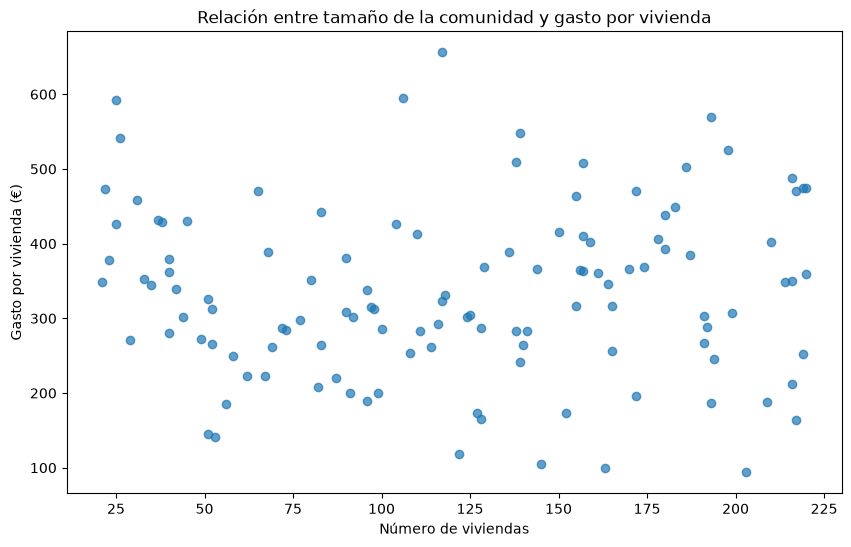

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_analisis["numero_viviendas"],
    df_analisis["gasto_por_vivienda"],
    alpha=0.7
)

plt.xlabel("Número de viviendas")
plt.ylabel("Gasto por vivienda (€)")
plt.title("Relación entre tamaño de la comunidad y gasto por vivienda")

plt.show()

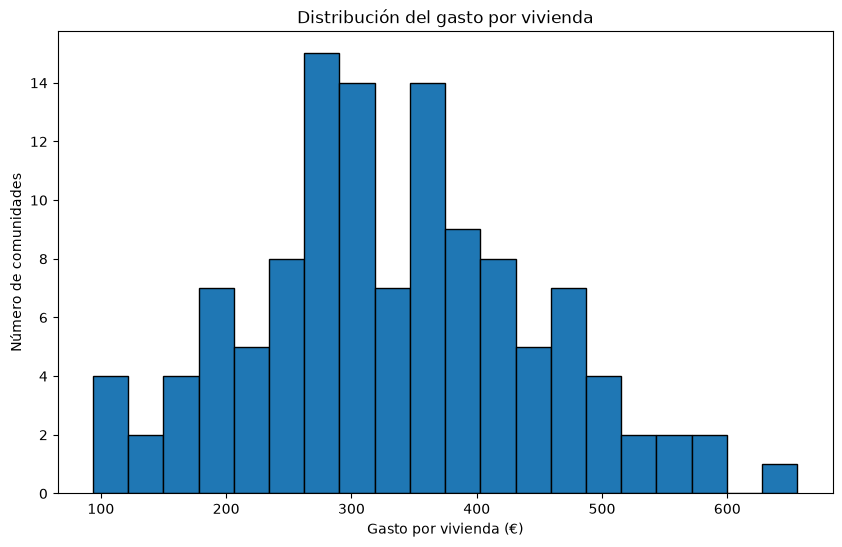

In [59]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_analisis["gasto_por_vivienda"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Gasto por vivienda (€)")
plt.ylabel("Número de comunidades")
plt.title("Distribución del gasto por vivienda")

plt.show()

In [60]:
df_analisis["gasto_por_vivienda"].describe().round(2)

count    120.00
mean     334.01
std      113.71
min       93.61
25%      263.52
50%      324.86
75%      407.22
max      655.92
Name: gasto_por_vivienda, dtype: float64

In [61]:
columnas_numericas = [
    "numero_viviendas",
    "anio_construccion",
    "numero_ascensores",
    "piscina",
    "garaje",
    "jardin",
    "conserjeria",
    "gasto_por_vivienda"
]

correlaciones = (
    df_analisis[columnas_numericas]
    .astype(float)
    .corr()["gasto_por_vivienda"]
    .sort_values(ascending=False)
)

display(correlaciones)

gasto_por_vivienda    1.000000
conserjeria           0.314232
piscina               0.138375
anio_construccion     0.126478
numero_ascensores     0.072847
jardin                0.051752
numero_viviendas      0.014735
garaje                0.008939
Name: gasto_por_vivienda, dtype: float64

In [62]:
display(
    df_analisis
    .groupby("grupo_tamano", observed=True)
    .agg(
        comunidades=("comunidad_id", "count"),
        viviendas_media=("numero_viviendas", "mean"),
        gasto_mediano_vivienda=("gasto_por_vivienda", "median"),
        gasto_medio_vivienda=("gasto_por_vivienda", "mean")
    )
    .round(2)
)

,comunidades,viviendas_media,gasto_mediano_vivienda,gasto_medio_vivienda
grupo_tamano,,,,
Muy pequeña,19,33.95,378.75,390.23
Pequeña,30,76.33,284.82,279.29
Mediana,27,126.44,302.42,331.85
Grande,31,174.16,364.57,356.47
Muy grande,13,215.08,350.29,329.06


In [63]:
benchmark = (
    df_analisis
    .groupby(
        ["grupo_tamano", "conserjeria", "piscina"],
        observed=True
    )
    .agg(
        comunidades_comparables=("comunidad_id", "count"),
        mediana_grupo=("gasto_por_vivienda", "median")
    )
    .reset_index()
)

display(benchmark)

,grupo_tamano,conserjeria,piscina,comunidades_comparables,mediana_grupo
0,Muy pequeña,False,False,19,378.750870
1,Pequeña,False,False,17,261.834348
2,Pequeña,False,True,9,302.275870
3,Pequeña,True,True,4,243.090618
4,Mediana,False,False,8,252.875079
5,Mediana,False,True,3,261.189211
6,Mediana,True,False,4,402.465018
7,Mediana,True,True,12,367.233135
8,Grande,False,False,2,296.553739
9,Grande,False,True,7,316.110129


In [64]:
df_benchmark = df_analisis.merge(
    benchmark,
    on=["grupo_tamano", "conserjeria", "piscina"],
    how="left"
)

In [65]:
df_benchmark["desviacion_pct"] = (
    (
        df_benchmark["gasto_por_vivienda"]
        - df_benchmark["mediana_grupo"]
    )
    / df_benchmark["mediana_grupo"]
) * 100

In [66]:
display(
    df_benchmark[
        [
            "comunidad_id",
            "nombre",
            "grupo_tamano",
            "conserjeria",
            "piscina",
            "gasto_por_vivienda",
            "mediana_grupo",
            "desviacion_pct",
            "comunidades_comparables"
        ]
    ]
    .sort_values("desviacion_pct", ascending=False)
    .head(15)
    .round(2)
)

,comunidad_id,nombre,grupo_tamano,conserjeria,piscina,gasto_por_vivienda,mediana_grupo,desviacion_pct,comunidades_comparables
26,27,Comunidad Via de Morena Bermudez,Muy grande,True,False,487.35,251.99,93.40,3
106,107,Comunidad Paseo de Lorenza Montalbán,Pequeña,False,False,471.00,261.83,79.89,17
95,96,Comunidad Avenida de Edmundo Pino,Mediana,True,True,655.92,367.23,78.61,12
35,36,Comunidad Pasaje Marina Alonso,Mediana,True,True,594.86,367.23,61.98,12
29,30,Comunidad Glorieta de Clarisa Alsina,Muy pequeña,False,False,592.88,378.75,56.54,19
34,35,Comunidad Vial Pancho Saldaña,Mediana,True,True,547.61,367.23,49.12,12
69,70,Comunidad Cuesta Olga Alegre,Pequeña,False,False,388.80,261.83,48.49,17
84,85,Comunidad Cañada de Nazaret Andrés,Pequeña,False,True,442.24,302.28,46.30,9
85,86,Comunidad Calle Nydia Cisneros,Pequeña,False,False,380.25,261.83,45.23,17
73,74,Comunidad Ronda Chema Gras,Grande,True,True,569.38,397.51,43.24,16


In [67]:
alertas = (
    df_benchmark[
        df_benchmark["comunidades_comparables"] >= 5
    ]
    .sort_values("desviacion_pct", ascending=False)
)

display(
    alertas[
        [
            "comunidad_id",
            "nombre",
            "grupo_tamano",
            "conserjeria",
            "piscina",
            "gasto_por_vivienda",
            "mediana_grupo",
            "desviacion_pct",
            "comunidades_comparables"
        ]
    ]
    .head(10)
    .round(2)
)

,comunidad_id,nombre,grupo_tamano,conserjeria,piscina,gasto_por_vivienda,mediana_grupo,desviacion_pct,comunidades_comparables
106,107,Comunidad Paseo de Lorenza Montalbán,Pequeña,False,False,471.00,261.83,79.89,17
95,96,Comunidad Avenida de Edmundo Pino,Mediana,True,True,655.92,367.23,78.61,12
35,36,Comunidad Pasaje Marina Alonso,Mediana,True,True,594.86,367.23,61.98,12
29,30,Comunidad Glorieta de Clarisa Alsina,Muy pequeña,False,False,592.88,378.75,56.54,19
34,35,Comunidad Vial Pancho Saldaña,Mediana,True,True,547.61,367.23,49.12,12
69,70,Comunidad Cuesta Olga Alegre,Pequeña,False,False,388.80,261.83,48.49,17
84,85,Comunidad Cañada de Nazaret Andrés,Pequeña,False,True,442.24,302.28,46.30,9
85,86,Comunidad Calle Nydia Cisneros,Pequeña,False,False,380.25,261.83,45.23,17
73,74,Comunidad Ronda Chema Gras,Grande,True,True,569.38,397.51,43.24,16
93,94,Comunidad C. Estefanía Yáñez,Muy pequeña,False,False,541.57,378.75,42.99,19


In [68]:
df_benchmark["alerta_gasto"] = (
    (df_benchmark["desviacion_pct"] >= 15) &
    (df_benchmark["comunidades_comparables"] >= 5)
)

print("Comunidades con alerta:", df_benchmark["alerta_gasto"].sum())

Comunidades con alerta: 30


In [69]:
display(
    df_benchmark[df_benchmark["alerta_gasto"]]
    [
        [
            "nombre",
            "gasto_por_vivienda",
            "mediana_grupo",
            "desviacion_pct",
            "comunidades_comparables"
        ]
    ]
    .sort_values("desviacion_pct", ascending=False)
    .round(2)
)

,nombre,gasto_por_vivienda,mediana_grupo,desviacion_pct,comunidades_comparables
106,Comunidad Paseo de Lorenza Montalbán,471.00,261.83,79.89,17
95,Comunidad Avenida de Edmundo Pino,655.92,367.23,78.61,12
35,Comunidad Pasaje Marina Alonso,594.86,367.23,61.98,12
29,Comunidad Glorieta de Clarisa Alsina,592.88,378.75,56.54,19
34,Comunidad Vial Pancho Saldaña,547.61,367.23,49.12,12
69,Comunidad Cuesta Olga Alegre,388.80,261.83,48.49,17
84,Comunidad Cañada de Nazaret Andrés,442.24,302.28,46.30,9
85,Comunidad Calle Nydia Cisneros,380.25,261.83,45.23,17
73,Comunidad Ronda Chema Gras,569.38,397.51,43.24,16
93,Comunidad C. Estefanía Yáñez,541.57,378.75,42.99,19


In [70]:
id_objetivo = 107

comunidad_objetivo = df_benchmark[
    df_benchmark["comunidad_id"] == id_objetivo
].iloc[0]

comparables = df_benchmark[
    (df_benchmark["grupo_tamano"] == comunidad_objetivo["grupo_tamano"]) &
    (df_benchmark["conserjeria"] == comunidad_objetivo["conserjeria"]) &
    (df_benchmark["piscina"] == comunidad_objetivo["piscina"])
]

ids_comparables = comparables["comunidad_id"].tolist()

print("Número de comparables:", len(ids_comparables))

Número de comparables: 17


In [71]:
gasto_categoria = (
    df_gastos_sql
    .groupby(["comunidad_id", "categoria"], as_index=False)
    .agg(gasto_categoria=("importe", "sum"))
)

gasto_categoria = gasto_categoria.merge(
    df_comunidades_sql[
        ["comunidad_id", "numero_viviendas"]
    ],
    on="comunidad_id",
    how="left"
)

gasto_categoria["gasto_categoria_vivienda"] = (
    gasto_categoria["gasto_categoria"] /
    gasto_categoria["numero_viviendas"]
)

In [72]:
gasto_objetivo = gasto_categoria[
    gasto_categoria["comunidad_id"] == id_objetivo
][
    ["categoria", "gasto_categoria_vivienda"]
]

benchmark_categoria = (
    gasto_categoria[
        gasto_categoria["comunidad_id"].isin(ids_comparables)
    ]
    .groupby("categoria", as_index=False)
    .agg(
        mediana_categoria=("gasto_categoria_vivienda", "median")
    )
)

comparacion_categoria = gasto_objetivo.merge(
    benchmark_categoria,
    on="categoria",
    how="left"
)

comparacion_categoria["desviacion_pct"] = (
    (
        comparacion_categoria["gasto_categoria_vivienda"]
        - comparacion_categoria["mediana_categoria"]
    )
    / comparacion_categoria["mediana_categoria"]
) * 100

display(
    comparacion_categoria
    .sort_values("desviacion_pct", ascending=False)
    .round(2)
)

,categoria,gasto_categoria_vivienda,mediana_categoria,desviacion_pct
5,Reparación extraordinaria,101.63,37.99,167.55
7,Suministros,51.71,31.26,65.41
4,Limpieza,141.94,88.79,59.85
6,Seguro,33.37,29.39,13.53
2,Fontanería,29.48,26.23,12.39
1,Electricidad,29.14,28.69,1.56
3,Garajes,51.51,51.48,0.06
8,Tasas,22.69,40.19,-43.55
0,Ascensores,9.54,20.66,-53.82


In [73]:
resultados_categorias = []

for _, comunidad in df_benchmark.iterrows():

    # Comunidades pertenecientes al mismo grupo comparable
    comparables = df_benchmark[
        (df_benchmark["grupo_tamano"] == comunidad["grupo_tamano"]) &
        (df_benchmark["conserjeria"] == comunidad["conserjeria"]) &
        (df_benchmark["piscina"] == comunidad["piscina"])
    ]

    ids_comparables = comparables["comunidad_id"].tolist()

    # Gastos de la comunidad analizada
    gastos_comunidad = gasto_categoria[
        gasto_categoria["comunidad_id"] == comunidad["comunidad_id"]
    ]

    # Mediana por categoría de su grupo comparable
    medianas = (
        gasto_categoria[
            gasto_categoria["comunidad_id"].isin(ids_comparables)
        ]
        .groupby("categoria")["gasto_categoria_vivienda"]
        .median()
    )

    for _, gasto in gastos_comunidad.iterrows():

        categoria = gasto["categoria"]
        gasto_real = gasto["gasto_categoria_vivienda"]

        if categoria in medianas.index:
            mediana = medianas[categoria]

            if mediana > 0:
                desviacion = ((gasto_real - mediana) / mediana) * 100

                resultados_categorias.append({
                    "comunidad_id": comunidad["comunidad_id"],
                    "nombre": comunidad["nombre"],
                    "categoria": categoria,
                    "gasto_categoria_vivienda": gasto_real,
                    "mediana_categoria": mediana,
                    "desviacion_categoria_pct": desviacion
                })

df_categorias_benchmark = pd.DataFrame(resultados_categorias)

In [74]:
display(df_categorias_benchmark.head(10).round(2))

,comunidad_id,nombre,categoria,gasto_categoria_vivienda,mediana_categoria,desviacion_categoria_pct
0,1,Comunidad Alameda Emperatriz Checa,Ascensores,35.33,29.92,18.10
1,1,Comunidad Alameda Emperatriz Checa,Garajes,6.14,5.86,4.64
2,1,Comunidad Alameda Emperatriz Checa,Jardinería,31.77,41.37,-23.21
3,1,Comunidad Alameda Emperatriz Checa,Limpieza,91.85,90.58,1.41
4,1,Comunidad Alameda Emperatriz Checa,Reparaciones generales,18.72,18.72,0.00
5,1,Comunidad Alameda Emperatriz Checa,Reparación extraordinaria,54.71,54.71,0.00
6,1,Comunidad Alameda Emperatriz Checa,Seguridad,172.96,163.40,5.85
7,1,Comunidad Alameda Emperatriz Checa,Seguro,14.01,9.65,45.22
8,1,Comunidad Alameda Emperatriz Checa,Suministros,8.10,17.25,-53.06
9,1,Comunidad Alameda Emperatriz Checa,Tasas,15.22,14.83,2.67


In [75]:
df_benchmark["alerta_gasto"] = (
    (df_benchmark["desviacion_pct"] >= 15) &
    (df_benchmark["comunidades_comparables"] >= 5)
)

In [76]:
ids_alerta = df_benchmark.loc[
    df_benchmark["alerta_gasto"],
    "comunidad_id"
].tolist()

categorias_alertas = df_categorias_benchmark[
    df_categorias_benchmark["comunidad_id"].isin(ids_alerta)
].copy()

In [77]:
categorias_problematicas = categorias_alertas[
    categorias_alertas["desviacion_categoria_pct"] >= 25
]

resumen_categorias = (
    categorias_problematicas
    .groupby("categoria")
    .agg(
        comunidades_afectadas=("comunidad_id", "nunique"),
        desviacion_mediana=("desviacion_categoria_pct", "median")
    )
    .sort_values("comunidades_afectadas", ascending=False)
    .round(2)
)

display(resumen_categorias)

,comunidades_afectadas,desviacion_mediana
categoria,,
Seguro,13,83.76
Limpieza,12,57.71
Suministros,12,96.57
Reparación extraordinaria,11,93.40
Tasas,11,77.72
Ascensores,8,74.83
Seguridad,7,46.64
Electricidad,5,72.69
Fontanería,4,47.19


In [78]:
causa_principal = (
    categorias_alertas
    .sort_values(
        "desviacion_categoria_pct",
        ascending=False
    )
    .groupby("comunidad_id")
    .first()
    .reset_index()
)

causa_principal = causa_principal[
    [
        "comunidad_id",
        "nombre",
        "categoria",
        "desviacion_categoria_pct"
    ]
]

display(causa_principal.head(10).round(2))

,comunidad_id,nombre,categoria,desviacion_categoria_pct
0,1,Comunidad Alameda Emperatriz Checa,Seguro,45.22
1,5,Comunidad Urbanización Alonso Esteban,Seguro,194.34
2,7,Comunidad Cañada de Ramiro Rocamora,Reparación extraordinaria,115.28
3,20,Comunidad C. de Jose Ramón Bustos,Seguro,157.71
4,24,Comunidad Rambla Maura Noguera,Suministros,80.51
5,30,Comunidad Glorieta de Clarisa Alsina,Suministros,250.61
6,31,Comunidad Vial de Manuelita Fuente,Seguro,182.52
7,34,Comunidad Glorieta de Celestino Alegre,Ascensores,46.22
8,35,Comunidad Vial Pancho Saldaña,Suministros,95.65
9,36,Comunidad Pasaje Marina Alonso,Ascensores,93.80


In [79]:
df_categorias_benchmark["exceso_euros_vivienda"] = (
    df_categorias_benchmark["gasto_categoria_vivienda"]
    - df_categorias_benchmark["mediana_categoria"]
)

In [80]:
df_benchmark
conn

In [81]:
print(df_benchmark.shape)

(120, 19)


In [83]:
import mssql_python

conn = mssql_python.connect(
    "Server=myresidential-sql.database.windows.net;"
    "Database=myresidential_db;"
    "Authentication=ActiveDirectoryDefault;"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
)

cursor = conn.cursor()

print("Conexión restablecida")

Conexión restablecida


In [84]:
cursor.execute("SELECT COUNT(*) FROM benchmark_comunidades")
print("Filas actuales:", cursor.fetchone()[0])

Filas actuales: 0


In [85]:
datos_benchmark = []

for _, fila in df_benchmark.iterrows():
    datos_benchmark.append((
        int(fila["comunidad_id"]),
        float(fila["gasto_por_vivienda"]),
        float(fila["mediana_grupo"]),
        float(fila["desviacion_pct"]),
        int(fila["comunidades_comparables"]),
        bool(fila["alerta_gasto"])
    ))

In [86]:
print(len(datos_benchmark))
print(datos_benchmark[:3])

120
[(1, 448.8012568306011, 374.0730806566981, 19.976892227239436, 6, True), (2, 402.2049685534591, 397.5102898322851, 1.1810206782709318, 16, False), (3, 99.57466257668712, 397.5102898322851, -74.9504188636981, 16, False)]


In [87]:
cursor.executemany("""
    INSERT INTO benchmark_comunidades (
        comunidad_id,
        gasto_por_vivienda,
        mediana_grupo,
        desviacion_pct,
        comunidades_comparables,
        alerta_gasto
    )
    VALUES (?, ?, ?, ?, ?, ?)
""", datos_benchmark)

conn.commit()

print("Benchmark guardado en Azure")

Benchmark guardado en Azure


In [88]:
cursor.execute("SELECT COUNT(*) FROM benchmark_comunidades")
print("Filas en Azure:", cursor.fetchone()[0])

Filas en Azure: 120


In [89]:
print(df_categorias_benchmark.columns.tolist())
print(df_categorias_benchmark.shape)

df_categorias_benchmark.head()

['comunidad_id', 'nombre', 'categoria', 'gasto_categoria_vivienda', 'mediana_categoria', 'desviacion_categoria_pct', 'exceso_euros_vivienda']
(988, 7)


,comunidad_id,nombre,categoria,gasto_categoria_vivienda,mediana_categoria,desviacion_categoria_pct,exceso_euros_vivienda
0,1,Comunidad Alameda Emperatriz Checa,Ascensores,35.332240,29.917589,18.098554,5.414651
1,1,Comunidad Alameda Emperatriz Checa,Garajes,6.136339,5.864149,4.641595,0.272190
2,1,Comunidad Alameda Emperatriz Checa,Jardinería,31.769126,41.369767,-23.206903,-9.600642
3,1,Comunidad Alameda Emperatriz Checa,Limpieza,91.854044,90.579477,1.407126,1.274567
4,1,Comunidad Alameda Emperatriz Checa,Reparaciones generales,18.719399,18.719399,0.000000,0.000000


In [90]:
datos_categorias = []

for _, fila in df_categorias_benchmark.iterrows():
    datos_categorias.append((
        int(fila["comunidad_id"]),
        str(fila["categoria"]),
        float(fila["gasto_categoria_vivienda"]),
        float(fila["mediana_categoria"]),
        float(fila["desviacion_categoria_pct"])
    ))

print("Filas preparadas:", len(datos_categorias))
print(datos_categorias[:3])

Filas preparadas: 988
[(1, 'Ascensores', 35.33224043715847, 29.917589290744182, 18.0985543112909), (1, 'Garajes', 6.136338797814208, 5.864148780350403, 4.6415946739935965), (1, 'Jardinería', 31.76912568306011, 41.36976744186047, -23.206902896644856)]


In [92]:
import mssql_python

conn = mssql_python.connect(
    "Server=myresidential-sql.database.windows.net;"
    "Database=myresidential_db;"
    "Authentication=ActiveDirectoryDefault;"
    "Encrypt=yes;"
    "TrustServerCertificate=no;"
)

cursor = conn.cursor()

In [93]:
cursor.execute("SELECT COUNT(*) FROM comunidades")
print(cursor.fetchone())

(120)


In [94]:
cursor.execute("SELECT COUNT(*) FROM benchmark_categorias")
print("Filas actuales:", cursor.fetchone()[0])

Filas actuales: 0


In [95]:
tamano_bloque = 100

for inicio in range(0, len(datos_categorias), tamano_bloque):
    fin = inicio + tamano_bloque
    bloque = datos_categorias[inicio:fin]

    cursor.executemany("""
        INSERT INTO benchmark_categorias (
            comunidad_id,
            categoria,
            gasto_por_vivienda,
            mediana_categoria,
            desviacion_pct
        )
        VALUES (?, ?, ?, ?, ?)
    """, bloque)

    conn.commit()

    print(f"Insertadas filas {inicio} a {min(fin, len(datos_categorias))}")

Insertadas filas 0 a 100
Insertadas filas 100 a 200
Insertadas filas 200 a 300
Insertadas filas 300 a 400
Insertadas filas 400 a 500
Insertadas filas 500 a 600
Insertadas filas 600 a 700
Insertadas filas 700 a 800
Insertadas filas 800 a 900
Insertadas filas 900 a 988


In [96]:
cursor.execute("SELECT COUNT(*) FROM benchmark_categorias")
print("Filas en Azure:", cursor.fetchone()[0])

Filas en Azure: 988
